# Final Lab Project

Name: Cole Stevens

### Goal

The goal is to use a potentiometer to determine how many of a series of LED's are turned on.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
import pyvisa

### Tasks Outline

**1. Potentiometer:** Assemble a simple potentiometer circuit with a 6 V power supply, potentiometer, voltmeter, 1k Ohm resistor, and ground. Set the power supply to an arbitrary voltage and measure the voltage drop across the potentiometer as you turn the dial on the potentiometer.<br> **Collect this data** using a time function on the Digital Multimeter (DMM). 

Circuit diagram

In [3]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL2::INSTR',
 'ASRL10::INSTR',
 'GPIB0::10::INSTR',
 'GPIB0::22::INSTR',
 'GPIB0::5::INSTR',
 'USB0::0x0957::0x179B::MY52166481::0::INSTR')

In [4]:
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-2



In [8]:
V_in = 5 
t_meas = []
V_pot = []
t = time.time()
T = time.time() + 15

while t < T:
    t_meas.append(t)
    readvolt = dmm.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    V_pot.append(readvolt)
    time.sleep(0.5)
    t = time.time()
print(t_meas)
print(V_pot)

[1773091348.8876843, 1773091350.395055, 1773091351.9028997, 1773091353.4089901, 1773091354.916659, 1773091356.4238143, 1773091357.930184, 1773091359.4361875, 1773091360.943601, 1773091362.450047]
[np.float64(0.025), np.float64(1.632), np.float64(3.082), np.float64(3.756), np.float64(4.087), np.float64(4.322), np.float64(4.486), np.float64(4.578), np.float64(4.609), np.float64(4.609)]


In [16]:
df = []
df = pd.DataFrame(t_meas)
df.to_csv('Potentiometer_Time_9Mar2026.csv', index = False)
df = []
df = pd.DataFrame(V_pot)
df.to_csv('Potentiometer_Voltage_Drop_9Mar2026.csv', index = False)

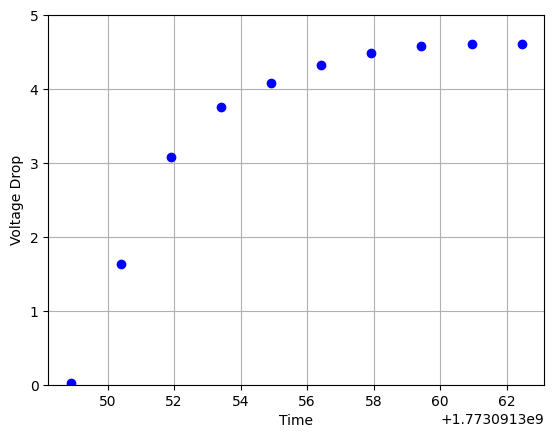

In [14]:
plt.plot(t_meas, V_pot, 'bo')
plt.grid(True)
plt.ylim(0,5)
plt.xlabel('Time')
plt.ylabel('Voltage Drop')
plt.savefig('Potentiometer_Voltage_Drop_9Mar2026.png')

In [4]:
V_pot = pd.read_csv('Potentiometer_Voltage_Drop_9Mar2026.csv')

In [9]:
print(V_pot)

[[0.025]
 [1.632]
 [3.082]
 [3.756]
 [4.087]
 [4.322]
 [4.486]
 [4.578]
 [4.609]
 [4.609]]


In [6]:
#V_pot = np.array(V_pot)
R_p = 982 / (5/V_pot - 1)
print(R_p)

[[4.93467337e+00]
 [4.75838480e+02]
 [1.57795829e+03]
 [2.96494534e+03]
 [4.39587514e+03]
 [6.25988791e+03]
 [8.57052918e+03]
 [1.06530711e+04]
 [1.15755448e+04]
 [1.15755448e+04]]


In [13]:
df = []
df = pd.DataFrame(R_p)
df.to_csv('Potentiometer_Resistance_9Mar2026.csv', index = False)

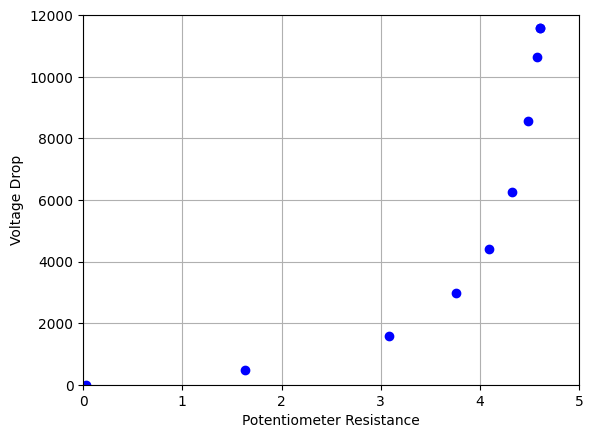

In [12]:
plt.plot(V_pot, R_p, 'bo')
plt.grid(True)
plt.ylim(0,12000)
plt.xlim(0,5)
plt.xlabel('Potentiometer Resistance (Ohm)')
plt.ylabel('Voltage Drop (V)')
plt.savefig('Pote_Resistance_Voltage_Drop_9Mar2026.png')

**2. Comparator: SEPERATELY** Assemble one LM311P op amp comparator circuit. Make sure to have;
   - V_cc- at Port 4 set to 0 V (send to ground)
   - V_cc+ at Port 8 set to the 6 V power supply
   - V_- at Port 3 set to the set voltage (the output voltage from the voltage divider goes here)
   - V_+ at Port 2 set to another variable power supply
   - A 1k Ohm resistor connecting Port 8 and Port 7.

**Measure** the resultant voltage coming out of Port 1 as you change V_+ (Port 2) from 0 V to 6 V. You should see the resultant voltage stay at around 0 V until V_+ equals 2.1 V, whereon the resultant voltage is about 2.1 V. Double check your circuit if this is not the case. If the behavior you see is the opposite as described, switch V_+ and V_-.<br>
**Collect this data** by using the computer to change the voltage input from the power supply and measure the voltage output using the DMM.<br>

V_cc+ set at 8V<br>
V_- set as variable power supply<br>
V_+ set as the point voltage<br>
R1 = 9.94 kOhm<br>
R2 = 3.316 kOhm<br>
<br>

In [3]:
rm = pyvisa.ResourceManager()
rm.list_resources()
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))
ps = rm.open_resource('GPIB0::5::INSTR')
print(ps.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-2

Agilent Technologies,E3646A,0,1.7-5.0-1.0



In [4]:
voltin = np.linspace(0,6, 20)
voltout = []
dmm.write('*RST')
for setvoltage in voltin:
    voltagestr = "APPL " + str(setvoltage) + ", 1.0"
    ps.write(voltagestr)
    voltoutstr = dmm.query("MEAS:VOLT:DC?", 1)
    voltout.append(float(voltoutstr))
print(voltin)
print(voltout)

[0.         0.31578947 0.63157895 0.94736842 1.26315789 1.57894737
 1.89473684 2.21052632 2.52631579 2.84210526 3.15789474 3.47368421
 3.78947368 4.10526316 4.42105263 4.73684211 5.05263158 5.36842105
 5.68421053 6.        ]
[0.22636103, 0.22671663, 0.22663161, 0.22663253, 0.22658369, 0.22658199, 0.22661137, 2.5627215, 2.5615153, 2.5609926, 2.5606777, 2.560496, 2.560398, 2.5603366, 2.5603065, 2.5602869, 2.5602503, 2.5602138, 2.5601576, 2.5600961]


In [5]:
df = []
df = pd.DataFrame(voltin)
df.to_csv('Comparator_Voltin_10Mar2026.csv', index = False)
df = []
df = pd.DataFrame(voltout)
df.to_csv('Comparator_Voltout_10Mar2026.csv', index = False)

Text(0.5, 0, 'Voltage In (V)')

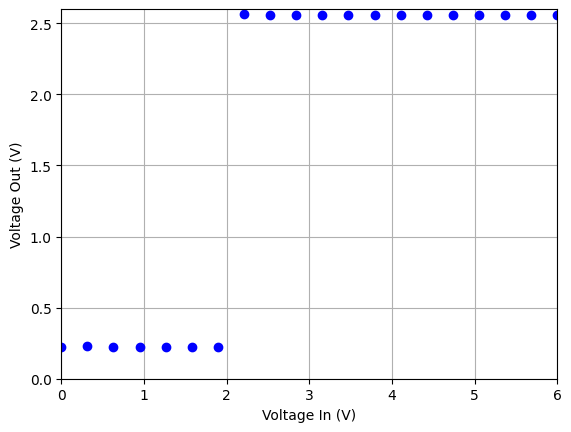

In [7]:
plt.plot(voltin, voltout, 'bo')
plt.grid(True)
plt.xlim(0,6)
plt.ylim(0,2.6)
plt.ylabel('Voltage Out (V)')
plt.xlabel('Voltage In (V)')

**3. Combining:** Connect the potentiometer circuit and the comparator circuit such that the output voltage from the potentiometer is the variable input for the first LED, with the LED's voltage output being the voltage input (V_+) for the comparator circuit.<br>
   **This circuit should be** -> 6V power supply, potentiometer, LED1, comparator circuit, ground.<br>
   Test the circuit by turning the potentiometer dial and measuring the output voltage from the comparator to ensure that the comparator is still working as desired, with the voltage input now determined by the potentiometer.

**4. Comparator LED:** Connect your second LED to the voltage output of your comparator. Test the circuit again, measuring the votlage drop across this second LED.<br>
   **This circuit should be** -> 6V power supply, potentiometer, LED1, comparator circuit, LED2, ground.

**5. Repeat Comparator:** Assemble and connect another comparator circuit the exact same as the first to the last diode in your circuit from step 3. Connect another LED onto the end of your second comparator.<br>
   **This circuit should be** -> 6V power supply, potentiometer, LED1, comparator circuit1, LED2, comparator2, LED3, ground.

**6. Repeat Step 4 Twice:** Repeat step 5 twice. You should now have five diodes in series connected in between with four comparators.<br>
   **This circuit should be** -> 6V power supply, potentiometer, LED1, comparator circuit1, LED2, comparator2, LED3, comparator3, LED4, comparator4, LED5, ground.

<span style="background-color:yellow">Steps 3 through 6 were done at the same time. Issues came up trying to follow the initial circuit diagram, so a new circuit was created putting three comparators in parallel to the voltage out of the potentiometer circuit.</span>

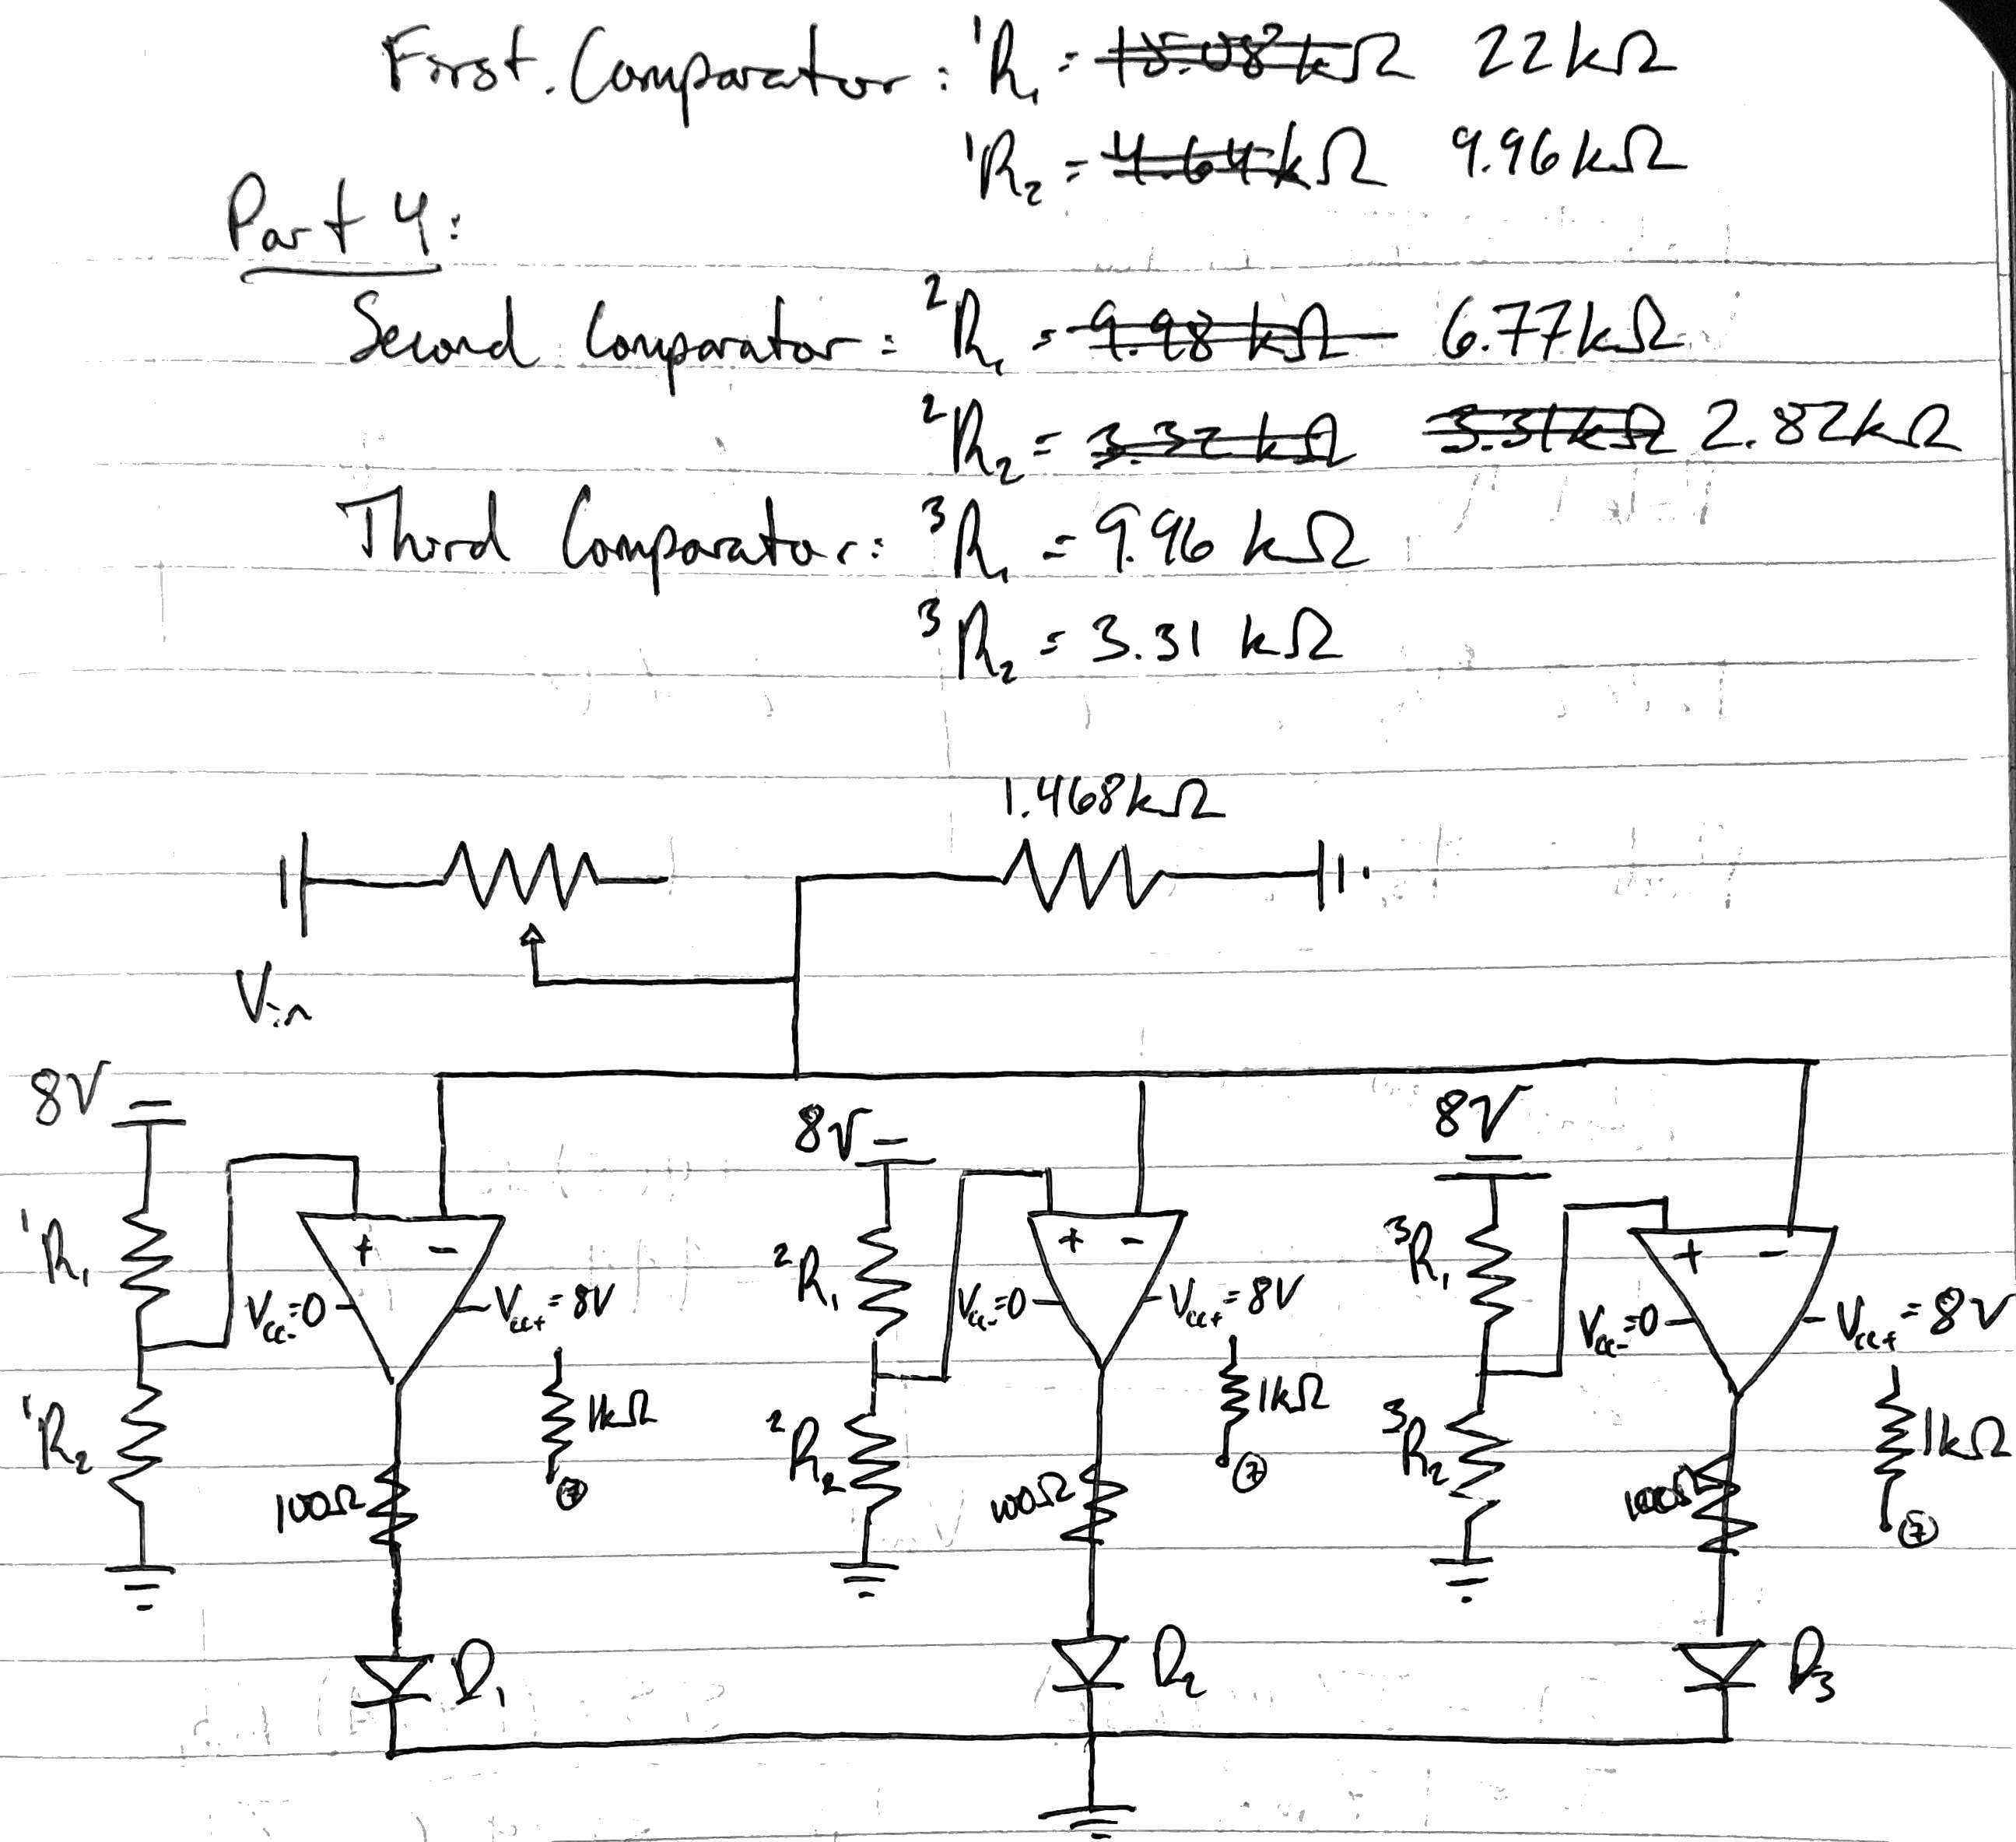

**7. Full Circuit Data:** Using a time function, repeatedly measure the voltage drop over LED1 as you *slowly* turn the potentiometer. Repeat this data acquisition for the following four LEDs.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import time
import pandas as pd
import pyvisa

In [1]:
import u3

In [3]:
labjack = u3.U3()
print(labjack.configU3())

{'FirmwareVersion': '1.44', 'BootloaderVersion': '0.27', 'HardwareVersion': '1.30', 'SerialNumber': 320055842, 'ProductID': 3, 'LocalID': 1, 'TimerCounterMask': 64, 'FIOAnalog': 15, 'FIODirection': 0, 'FIOState': 0, 'EIOAnalog': 0, 'EIODirection': 0, 'EIOState': 0, 'CIODirection': 0, 'CIOState': 0, 'DAC1Enable': 1, 'DAC0': 0, 'DAC1': 0, 'TimerClockConfig': 2, 'TimerClockDivisor': 256, 'CompatibilityOptions': 0, 'VersionInfo': 18, 'DeviceName': 'U3-HV'}


In [2]:
rm = pyvisa.ResourceManager()
dmm = rm.open_resource('GPIB0::22::INSTR')
print(dmm.query("*IDN?"))

HEWLETT-PACKARD,34401A,0,11-5-2



In [5]:
t_rec1 = []
vd1 = []
t = time.time()
T = time.time() + 10
while t < T:
    t_rec1.append(t)
    readvolt = dmm.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    vd1.append(readvolt)
    t = time.time()
print(t_rec1)
print(vd1)

[1773358777.0318444, 1773358778.0353186, 1773358779.041805, 1773358780.0506072, 1773358781.0645728, 1773358782.0695992, 1773358783.0746472, 1773358784.0794852, 1773358785.0833101, 1773358786.088626]
[np.float64(0.132), np.float64(0.132), np.float64(0.132), np.float64(0.132), np.float64(0.132), np.float64(0.132), np.float64(2.557), np.float64(2.556), np.float64(2.556), np.float64(2.556)]


In [6]:
df = []
df = pd.DataFrame(t_rec1)
df.to_csv('Time_record_1_12Mar2026.csv', index = False)
df = []
df = pd.DataFrame(vd1)
df.to_csv('Diode_volt_1_12Mar2026.csv', index = False)

In [8]:
t_rec2 = []
vd2 = []
t = time.time()
T = time.time() + 10
while t < T:
    t_rec2.append(t)
    readvolt = dmm.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    vd2.append(readvolt)
    t = time.time()
print(t_rec2)
print(vd2)

[1773358942.4485254, 1773358943.4509947, 1773358944.4620585, 1773358945.465632, 1773358946.4694784, 1773358947.4738307, 1773358948.494428, 1773358949.4987736, 1773358950.5031245, 1773358951.5082357]
[np.float64(0.149), np.float64(0.148), np.float64(0.148), np.float64(0.148), np.float64(0.148), np.float64(0.148), np.float64(0.148), np.float64(5.006), np.float64(4.982), np.float64(4.972)]


In [9]:
df = []
df = pd.DataFrame(t_rec2)
df.to_csv('Time_record_1_12Mar2026.csv', index = False)
df = []
df = pd.DataFrame(vd2)
df.to_csv('Diode_volt_1_12Mar2026.csv', index = False)

In [10]:
t_rec3 = []
vd3 = []
t = time.time()
T = time.time() + 10
while t < T:
    t_rec3.append(t)
    readvolt = dmm.query("MEAS:VOLT:DC?", 1)
    readvolt = np.round(float(readvolt), 3)
    vd3.append(readvolt)
    t = time.time()
print(t_rec3)
print(vd3)

[1773359015.1992123, 1773359016.2085638, 1773359017.2129145, 1773359018.2199059, 1773359019.2246222, 1773359020.2326808, 1773359021.2372332, 1773359022.2404299, 1773359023.2441819, 1773359024.2485795]
[np.float64(0.231), np.float64(0.231), np.float64(0.231), np.float64(0.231), np.float64(0.231), np.float64(0.231), np.float64(2.579), np.float64(2.581), np.float64(2.581), np.float64(2.581)]


In [11]:
df = []
df = pd.DataFrame(t_rec3)
df.to_csv('Time_record_1_12Mar2026.csv', index = False)
df = []
df = pd.DataFrame(vd3)
df.to_csv('Diode_volt_1_12Mar2026.csv', index = False)

Text(0.5, 0, 'Time (s)')

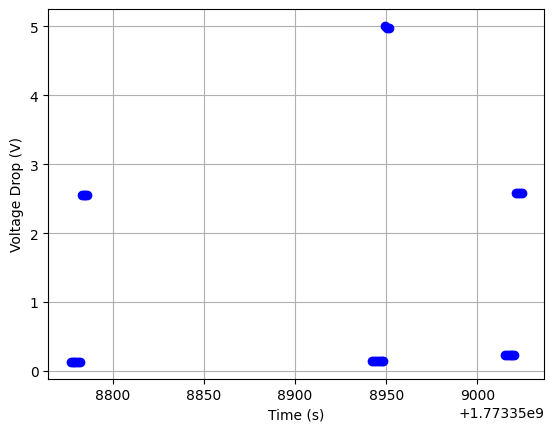

In [12]:
plt.plot(t_rec1, vd1, 'bo')
plt.plot(t_rec2, vd2, 'bo')
plt.plot(t_rec3, vd3, 'bo')
plt.grid(True)
plt.ylabel('Voltage Drop (V)')
plt.xlabel('Time (s)')

In [11]:
Time = []
diode1 = []
diode2 = []
diode3 = []
t = time.time()
T = time.time() + 10
while t < T:
    Time.append(t)
    voltage = labjack.getAIN(1)
    diode1.append(voltage)
    voltage = labjack.getAIN(2)
    diode2.append(voltage)
    voltage = labjack.getAIN(3)
    diode3.append(voltage)
    time.sleep(0.3)
    t = time.time()
print(Time)
print(diode1)
print(diode2)
print(diode3)

[1773434746.9439082, 1773434747.2480476, 1773434747.5521271, 1773434747.8560545, 1773434748.1610508, 1773434748.465556, 1773434748.769753, 1773434749.074513, 1773434749.3783433, 1773434749.6825373, 1773434749.986506, 1773434750.2907903, 1773434750.5947115, 1773434750.898151, 1773434751.202342, 1773434751.5065508, 1773434751.8104005, 1773434752.114055, 1773434752.4177804, 1773434752.7215238, 1773434753.0245337, 1773434753.328704, 1773434753.6322145, 1773434753.936313, 1773434754.2398748, 1773434754.5434496, 1773434754.8477883, 1773434755.1517196, 1773434755.4556918, 1773434755.7603364, 1773434756.064082, 1773434756.3692827, 1773434756.6730835]
[1.4260159999999988, 1.4260159999999988, 1.4260159999999988, 1.4260159999999988, 1.4209919999999983, 1.4260159999999988, 1.4310399999999994, 1.4260159999999988, 1.4209919999999983, 1.4209919999999983, 1.4260159999999988, 1.4260159999999988, 1.4260159999999988, 1.4209919999999983, 1.4260159999999988, 1.4260159999999988, 1.4260159999999988, 1.426015

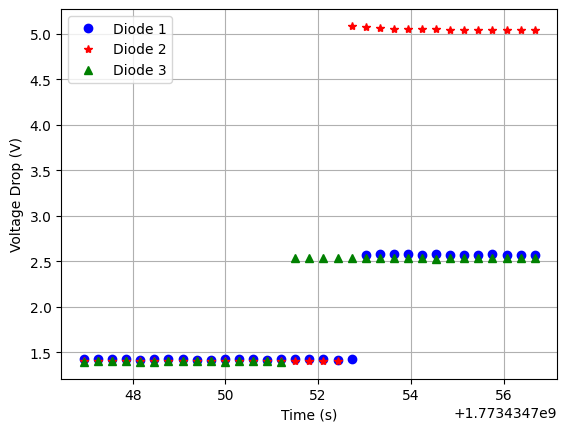

In [13]:
plt.plot(Time, diode1, 'bo', label = 'Diode 1')
plt.plot(Time, diode2, 'r*', label = 'Diode 2')
plt.plot(Time, diode3, 'g^', label = 'Diode 3')
plt.grid(True)
plt.legend()
plt.ylabel('Voltage Drop (V)')
plt.xlabel('Time (s)')
plt.savefig('Combined_Diode_Voltage_13Mar2026.png')

<span style="background-color:yellow">Seeing that the second diode had a voltage drop of 5 Volts, I tested the diode in a voltage divider. The diode contained all of the voltage until about 2.8V, but by the time V_in = 8 V, the voltage over the diode was 5 V.<br>
The diode was replaced with a new one. </span>

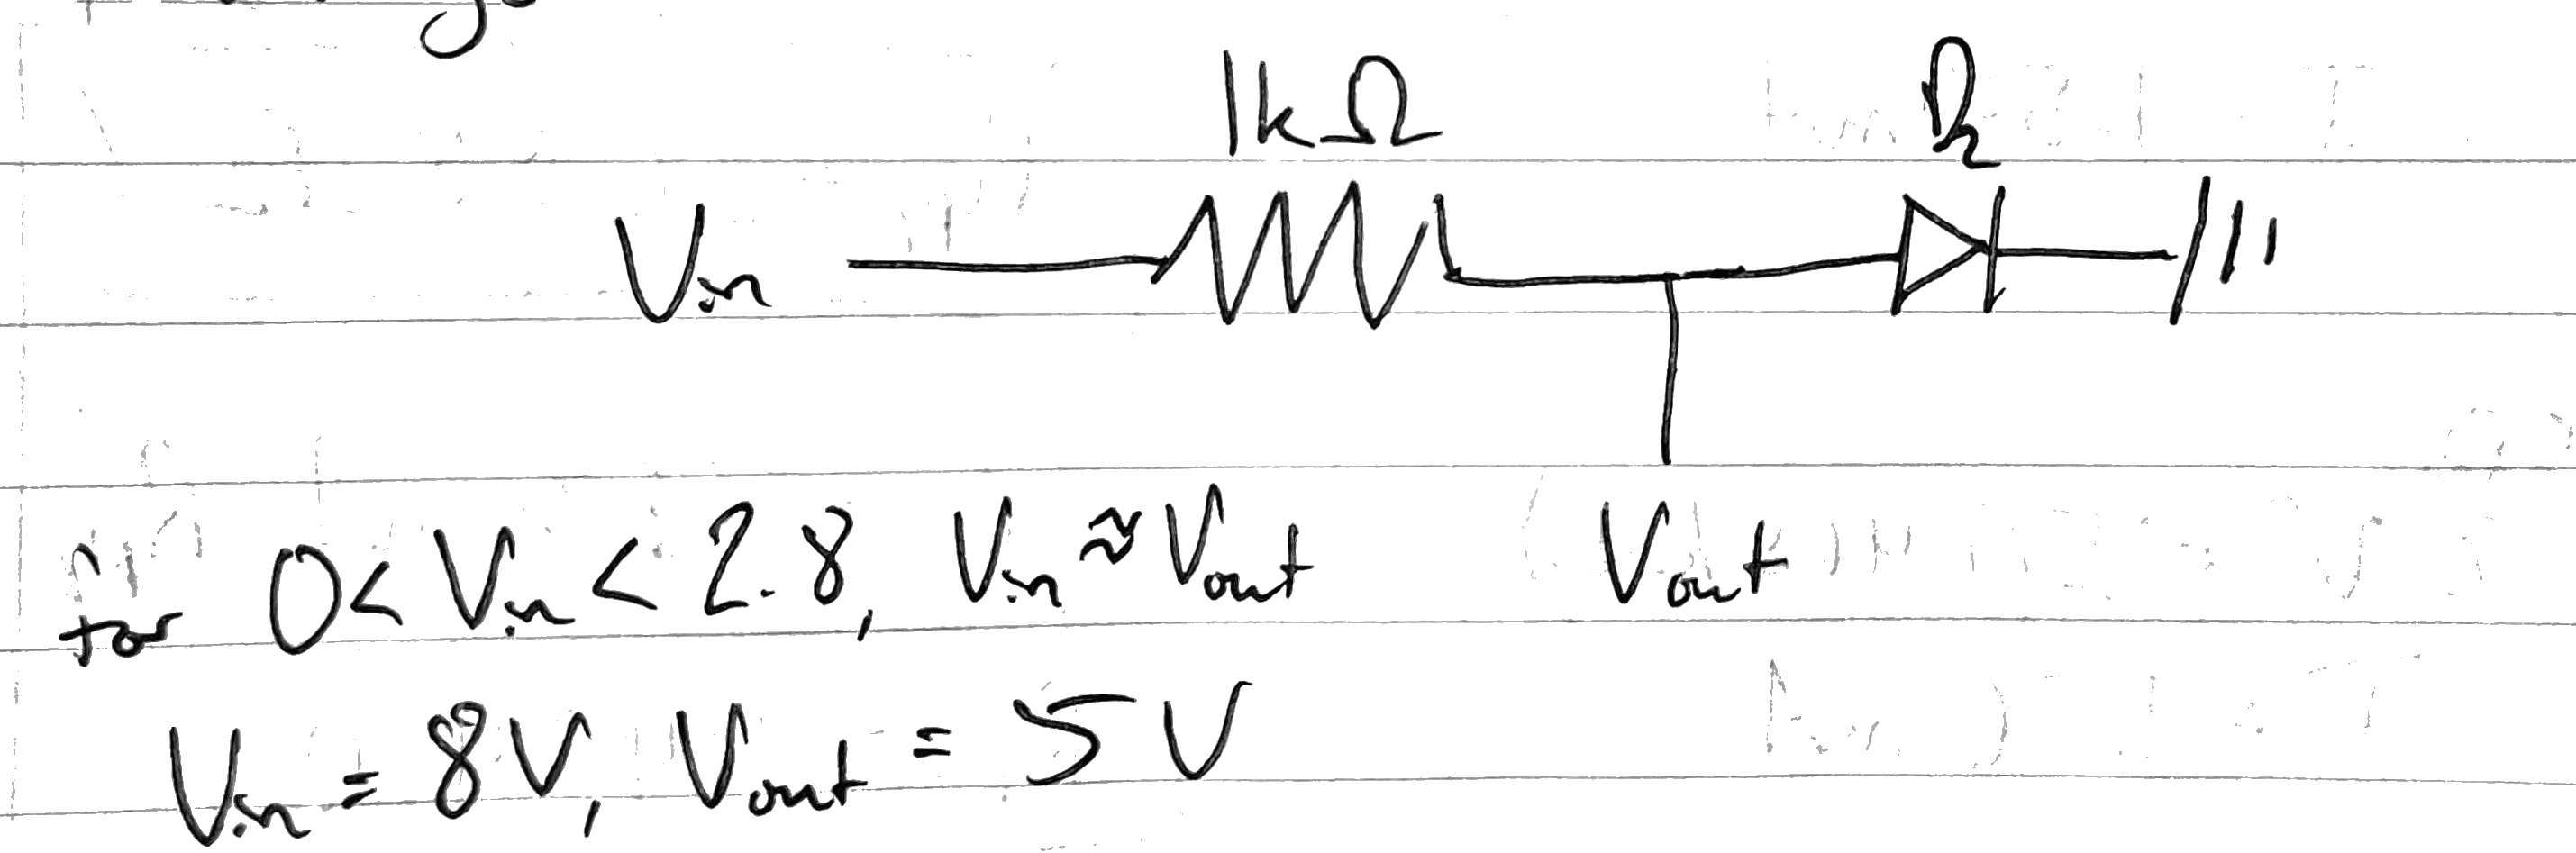

In [23]:
a = time.time()

In [24]:
Time = []
diode1 = []
diode2 = []
diode3 = []
resistor = []
potent = []
t = time.time()
T = time.time() + 10
while t < T:
    Time.append(t-a)
    voltage = labjack.getAIN(1)
    diode1.append(voltage)
    voltage = labjack.getAIN(2)
    diode2.append(voltage)
    voltage = labjack.getAIN(3)
    diode3.append(voltage)
    voltage = labjack.getAIN(0)
    resistor.append(voltage)
    potent.append(8)
    time.sleep(0.2)
    t = time.time()
print(Time)
print(diode1)
print(diode2)
print(diode3)
print(resistor)

[0.41918230056762695, 0.6228687763214111, 0.8277411460876465, 1.032804250717163, 1.2381646633148193, 1.4432055950164795, 1.6468474864959717, 1.851527214050293, 2.056375741958618, 2.2616307735443115, 2.467108726501465, 2.671945333480835, 2.8770737648010254, 3.0825107097625732, 3.2882080078125, 3.4934229850769043, 3.698472499847412, 3.90344500541687, 4.107804775238037, 4.312695264816284, 4.5172576904296875, 4.722945213317871, 4.927749395370483, 5.132570505142212, 5.336770534515381, 5.542763948440552, 5.748896837234497, 5.952397108078003, 6.157269477844238, 6.362323045730591, 6.567770004272461, 6.773245096206665, 6.977858066558838, 7.181578159332275, 7.386798858642578, 7.590313673019409, 7.795341730117798, 7.999096870422363, 8.203680992126465, 8.409030437469482, 8.616060972213745, 8.821996450424194, 9.026812314987183, 9.232223749160767, 9.437436580657959, 9.64261245727539, 9.84801721572876, 10.053497314453125, 10.258299589157104]
[1.4260159999999988, 1.4260159999999988, 1.4260159999999988

In [34]:
df = []
df = pd.DataFrame(Time)
df.to_csv('Time_13Mar2026.csv', index = False)
df = []
df = pd.DataFrame(diode1)
df.to_csv('Diode1_13Mar2026.csv', index = False)
df = []
df = pd.DataFrame(diode2)
df.to_csv('Diode2_13Mar2026.csv', index = False)
df = []
df = pd.DataFrame(diode3)
df.to_csv('Diode3_13Mar2026.csv', index = False)
df = []
df = pd.DataFrame(pot_volt)
df.to_csv('Potentiometer_voltage_13Mar2026.csv', index = False)

In [25]:
resistor = np.array(resistor)
pot_volt = potent - resistor

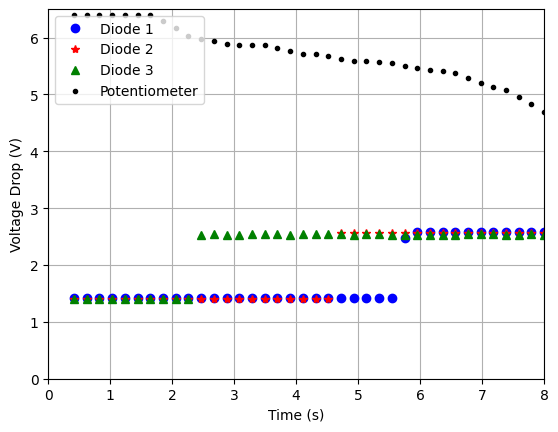

In [33]:
plt.plot(Time, diode1, 'bo', label = 'Diode 1')
plt.plot(Time, diode2, 'r*', label = 'Diode 2')
plt.plot(Time, diode3, 'g^', label = 'Diode 3')
plt.plot(Time, pot_volt, 'k.', label = 'Potentiometer')
plt.grid(True)
plt.legend(loc = 'upper left')
plt.ylabel('Voltage Drop (V)')
plt.xlabel('Time (s)')
plt.ylim(0,6.5)
plt.xlim(0,8)
plt.savefig('New_Combined_Diode_Voltage_13Mar2026.png')

Diode 1 turned on when $R_\text{potentiometer}$ = <span style="background-color:yellow">3229 $\ohm$</span> <br>
Diode 2 turned on when $R_\text{potentiometer}$ = <span style="background-color:yellow">3638 $\ohm$</span> <br>
Diode 3 turned on when $R_\text{potentiometer}$ = <span style="background-color:yellow">4404 $\ohm$</span> <br>